<a href="https://colab.research.google.com/github/abdulrafaykhan11/Machine-Predictive-Maintenance---ML/blob/main/Machine_Predictive_Maintenance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [99]:
df = pd.read_csv('predictive_maintenance.csv')

In [100]:
df

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure
...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,No Failure
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,No Failure
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,No Failure
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,No Failure


In [101]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [102]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


In [103]:
df['Target'].value_counts()

,count
Target,
0,9661
1,339


In [104]:
df[df['Target'] == 1]

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
50,51,L47230,L,298.9,309.1,2861,4.6,143,1,Power Failure
69,70,L47249,L,298.9,309.0,1410,65.7,191,1,Power Failure
77,78,L47257,L,298.8,308.9,1455,41.3,208,1,Tool Wear Failure
160,161,L47340,L,298.4,308.2,1282,60.7,216,1,Overstrain Failure
161,162,L47341,L,298.3,308.1,1412,52.3,218,1,Overstrain Failure
...,...,...,...,...,...,...,...,...,...,...
9758,9759,L56938,L,298.6,309.8,2271,16.2,218,1,Tool Wear Failure
9764,9765,L56944,L,298.5,309.5,1294,66.7,12,1,Power Failure
9822,9823,L57002,L,298.5,309.4,1360,60.9,187,1,Overstrain Failure
9830,9831,L57010,L,298.3,309.3,1337,56.1,206,1,Overstrain Failure


In [105]:
df = df.drop('UDI',axis=1)

In [106]:
df

,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure
...,...,...,...,...,...,...,...,...,...
9995,M24855,M,298.8,308.4,1604,29.5,14,0,No Failure
9996,H39410,H,298.9,308.4,1632,31.8,17,0,No Failure
9997,M24857,M,299.0,308.6,1645,33.4,22,0,No Failure
9998,H39412,H,299.0,308.7,1408,48.5,25,0,No Failure


In [107]:
df.describe()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


<Axes: >

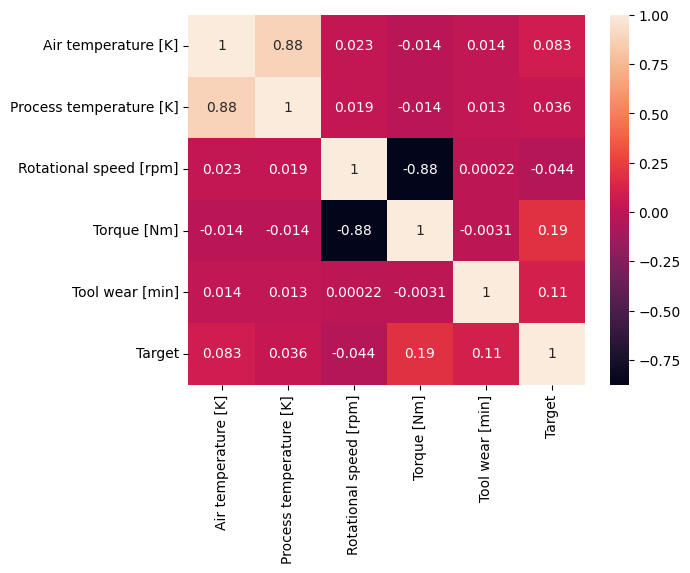

In [108]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

<Axes: xlabel='Air temperature [K]', ylabel='Count'>

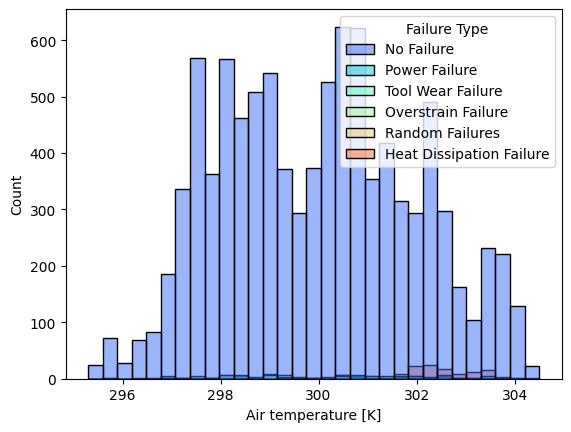

In [109]:
sns.histplot(x=df['Air temperature [K]'],hue=df['Failure Type'],palette='rainbow')

In [110]:
df['Failure Type'].value_counts()

,count
Failure Type,
No Failure,9652
Heat Dissipation Failure,112
Power Failure,95
Overstrain Failure,78
Tool Wear Failure,45
Random Failures,18


<Axes: xlabel='count', ylabel='Failure Type'>

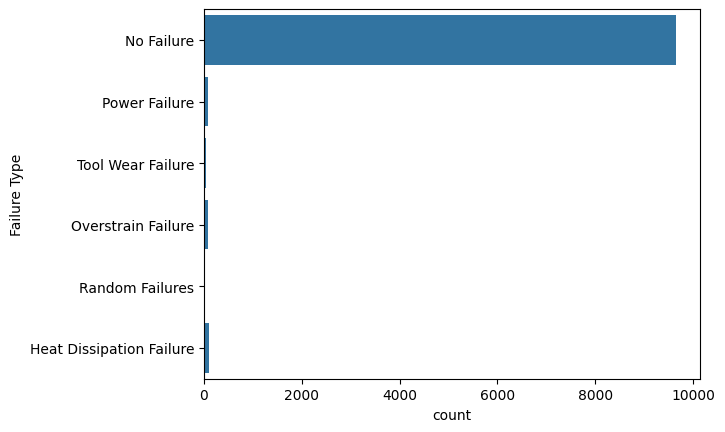

In [111]:
sns.countplot(df['Failure Type'])

In [112]:
df['power'] = df['Rotational speed [rpm]'] * df['Torque [Nm]']


In [113]:
df['temp_diff'] = df['Process temperature [K]'] - df['Air temperature [K]']

In [114]:
df = df.drop('Product ID',axis=1)

In [115]:
df

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type,power,temp_diff
0,M,298.1,308.6,1551,42.8,0,0,No Failure,66382.8,10.5
1,L,298.2,308.7,1408,46.3,3,0,No Failure,65190.4,10.5
2,L,298.1,308.5,1498,49.4,5,0,No Failure,74001.2,10.4
3,L,298.2,308.6,1433,39.5,7,0,No Failure,56603.5,10.4
4,L,298.2,308.7,1408,40.0,9,0,No Failure,56320.0,10.5
...,...,...,...,...,...,...,...,...,...,...
9995,M,298.8,308.4,1604,29.5,14,0,No Failure,47318.0,9.6
9996,H,298.9,308.4,1632,31.8,17,0,No Failure,51897.6,9.5
9997,M,299.0,308.6,1645,33.4,22,0,No Failure,54943.0,9.6
9998,H,299.0,308.7,1408,48.5,25,0,No Failure,68288.0,9.7


In [116]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Type                     10000 non-null  object 
 1   Air temperature [K]      10000 non-null  float64
 2   Process temperature [K]  10000 non-null  float64
 3   Rotational speed [rpm]   10000 non-null  int64  
 4   Torque [Nm]              10000 non-null  float64
 5   Tool wear [min]          10000 non-null  int64  
 6   Target                   10000 non-null  int64  
 7   Failure Type             10000 non-null  object 
 8   power                    10000 non-null  float64
 9   temp_diff                10000 non-null  float64
dtypes: float64(5), int64(3), object(2)
memory usage: 781.4+ KB


<Axes: xlabel='power', ylabel='Failure Type'>

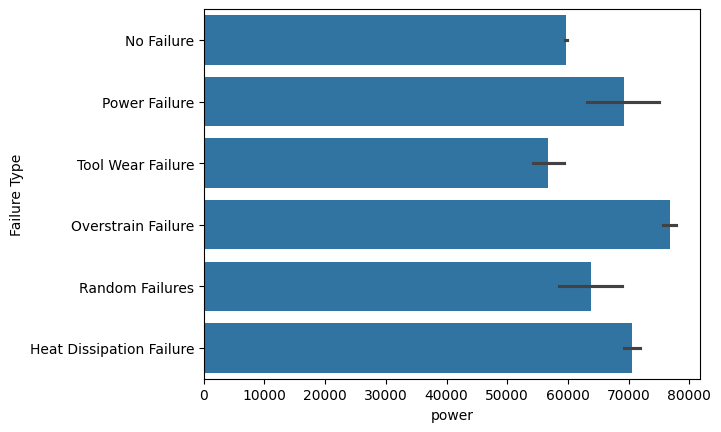

In [117]:
sns.barplot(x=df['power'],y=df['Failure Type'])

<Axes: xlabel='temp_diff', ylabel='Failure Type'>

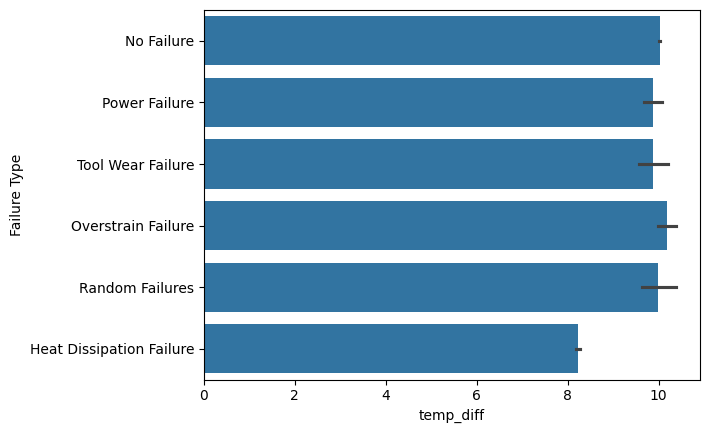

In [118]:
sns.barplot(x=df['temp_diff'], y=df['Failure Type'])

In [119]:
X = df.drop('Failure Type',axis=1)

In [120]:
y = df['Failure Type']

In [121]:
from  sklearn.model_selection import train_test_split

In [122]:
df_encoded = pd.get_dummies(df, columns=['Type'])

In [123]:
df_encoded

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type,power,temp_diff,Type_H,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,No Failure,66382.8,10.5,False,False,True
1,298.2,308.7,1408,46.3,3,0,No Failure,65190.4,10.5,False,True,False
2,298.1,308.5,1498,49.4,5,0,No Failure,74001.2,10.4,False,True,False
3,298.2,308.6,1433,39.5,7,0,No Failure,56603.5,10.4,False,True,False
4,298.2,308.7,1408,40.0,9,0,No Failure,56320.0,10.5,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,298.8,308.4,1604,29.5,14,0,No Failure,47318.0,9.6,False,False,True
9996,298.9,308.4,1632,31.8,17,0,No Failure,51897.6,9.5,True,False,False
9997,299.0,308.6,1645,33.4,22,0,No Failure,54943.0,9.6,False,False,True
9998,299.0,308.7,1408,48.5,25,0,No Failure,68288.0,9.7,True,False,False


In [124]:
df_encoded = df_encoded[['Type_H','Type_L','Type_M']].astype('Int64')

In [125]:
df_encoded

,Type_H,Type_L,Type_M
0,0,0,1
1,0,1,0
2,0,1,0
3,0,1,0
4,0,1,0
...,...,...,...
9995,0,0,1
9996,1,0,0
9997,0,0,1
9998,1,0,0


In [126]:
pd.crosstab(df['Target'], df['Failure Type'])


Failure Type,Heat Dissipation Failure,No Failure,Overstrain Failure,Power Failure,Random Failures,Tool Wear Failure
Target,,,,,,
0,0,9643,0,0,18,0
1,112,9,78,95,0,45


In [127]:

df_model = pd.get_dummies(df, columns=['Type'], dtype=int)

X = df_model.drop(['Failure Type', 'Target'], axis=1)
y = df_model['Failure Type']

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_label = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

In [128]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score,recall_score

In [129]:
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

LogisticRegression()

In [130]:
lr_pred = lr_model.predict(X_test)

In [131]:
accuracy_score(y_test, lr_pred)

0.965

In [132]:
report = classification_report(y_test, lr_pred)
print(report)

                          precision    recall  f1-score   support

Heat Dissipation Failure       0.00      0.00      0.00        22
              No Failure       0.97      1.00      0.98      1930
      Overstrain Failure       0.00      0.00      0.00        16
           Power Failure       0.00      0.00      0.00        19
         Random Failures       0.00      0.00      0.00         4
       Tool Wear Failure       0.00      0.00      0.00         9

                accuracy                           0.96      2000
               macro avg       0.16      0.17      0.16      2000
            weighted avg       0.93      0.96      0.95      2000



In [133]:
# pip install imbalanced-learn
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTENC

cat_cols = ['Type_H', 'Type_L', 'Type_M']
num_cols = [c for c in X_train.columns if c not in cat_cols]

# numeric scale honge, dummy columns jaise hain waise rahenge
# (output mein pehle numeric aate hain, phir cat columns)
prep = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', 'passthrough', cat_cols)
])
cat_idx = list(range(len(num_cols), len(num_cols) + len(cat_cols)))

# Har minority class ko kam az kam 500 samples tak le jao
# (default 'auto' har class ko ~7700 tak le jata hai, jo 14 rows wali class ke liye bohat zyada hai)
counts = y_train.value_counts()
strategy = {c: max(n, 500) for c, n in counts.items() if c != counts.idxmax()}

pipe = Pipeline([
    ('prep', prep),
    ('smote', SMOTENC(categorical_features=cat_idx,
                      sampling_strategy=strategy,
                      k_neighbors=3, random_state=42)),
    ('lr', LogisticRegression(max_iter=2000, random_state=42))
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
print(classification_report(y_test, y_pred))

                          precision    recall  f1-score   support

Heat Dissipation Failure       0.49      0.77      0.60        22
              No Failure       0.99      0.97      0.98      1930
      Overstrain Failure       0.67      1.00      0.80        16
           Power Failure       0.73      0.84      0.78        19
         Random Failures       0.00      0.00      0.00         4
       Tool Wear Failure       0.00      0.00      0.00         9

                accuracy                           0.96      2000
               macro avg       0.48      0.60      0.53      2000
            weighted avg       0.97      0.96      0.96      2000



In [134]:
from xgboost import XGBClassifier

In [136]:
# pip install xgboost imbalanced-learn
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTENC
from xgboost import XGBClassifier

# Function to sanitize column names for XGBoost
def sanitize_col_names(df):
    cols = df.columns
    new_cols = []
    for col in cols:
        new_col = col.replace('[', '').replace(']', '').replace('<', '').replace(' ', '_')
        new_cols.append(new_col)
    df.columns = new_cols
    return df

# Apply sanitation to X_train and X_test
X_train = sanitize_col_names(X_train.copy())
X_test = sanitize_col_names(X_test.copy())

# y ko encode karo (split ke baad, same encoder dono pe)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

cat_cols = ['Type_H', 'Type_L', 'Type_M']
cat_idx = [X_train.columns.get_loc(c) for c in cat_cols]

# Majority class ko chhor kar baqi classes ko kam az kam 500 tak le jao
counts = y_train.value_counts()
majority = le.transform([counts.idxmax()])[0]
strategy = {le.transform([c])[0]: max(n, 500)
            for c, n in counts.items() if c != counts.idxmax()}

pipe = Pipeline([
    ('smote', SMOTENC(categorical_features=cat_idx,
                      sampling_strategy=strategy,
                      k_neighbors=3, random_state=42)),
    ('xgb', XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=6,
        eval_metric='mlogloss',
        tree_method='hist',
        random_state=42
    ))
])

pipe.fit(X_train, y_train_enc)
y_pred = pipe.predict(X_test)

print(classification_report(y_test_enc, y_pred, target_names=le.classes_))

                          precision    recall  f1-score   support

Heat Dissipation Failure       0.92      1.00      0.96        22
              No Failure       0.99      0.99      0.99      1930
      Overstrain Failure       0.80      0.75      0.77        16
           Power Failure       1.00      0.95      0.97        19
         Random Failures       0.00      0.00      0.00         4
       Tool Wear Failure       0.00      0.00      0.00         9

                accuracy                           0.98      2000
               macro avg       0.62      0.62      0.62      2000
            weighted avg       0.98      0.98      0.98      2000

